<a href="https://colab.research.google.com/github/omega-u20/SmartCare-HospitalManagement/blob/main/Task4_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 04 – Exploratory Data Analysis (EDA)

## 0. Mount Google Drive and Load Data

We use the **original raw CSV** (not the fully encoded/scaled version) for EDA, because charts are much easier to read with real category names (e.g. `'Cardiology'`) and real units (e.g. `age` in years) rather than one-hot columns and standardised numbers.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATA_FOLDER = '/content/drive/MyDrive/CCS3440 - Asg 2'

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

df = pd.read_csv(f'{DATA_FOLDER}/smartcare_ai_dataset_1000.csv')

# Same cleaning decision as Task 03: room_type is only missing for non-admitted patients
df['room_type'] = df['room_type'].fillna('Not Admitted')

print('Dataset shape:', df.shape)
df.head()

Dataset shape: (1000, 33)


,record_id,patient_id,age,gender,blood_group,department,diagnosis,appointment_date,waiting_days,previous_appointments,missed_previous_appointments,appointment_status,admitted,room_type,length_of_stay_days,previous_admissions,systolic_bp,diastolic_bp,blood_sugar_mg_dl,cholesterol_mg_dl,bmi,lab_tests_count,treatments_count,consultation_fee_lkr,room_charge_lkr,lab_charge_lkr,medicine_charge_lkr,total_bill_lkr,payment_status,payment_method,no_show,readmitted_30_days,disease_risk_level
0,1,P10001,53,Male,A-,General Medicine,Migraine,2025-04-10,10,1,0,Completed,0,Not Admitted,0,1,127,75,117,211,26.1,0,3,2000,0,0,11596,13596,Paid,Insurance,0,0,High
1,2,P10002,26,Male,B-,General Medicine,Diabetes,2025-05-15,2,3,1,Completed,0,Not Admitted,0,0,130,73,136,173,32.8,0,1,2000,0,0,3652,5652,Paid,Insurance,0,0,Medium
2,3,P10003,22,Male,B+,Orthopedics,Back Pain,2025-07-09,22,7,1,No-Show,0,Not Admitted,0,1,141,64,90,176,29.4,1,0,2500,0,1200,2562,6262,Unpaid,Insurance,1,0,Medium
3,4,P10004,44,Female,AB-,Cardiology,Asthma,2025-10-16,16,1,0,Completed,0,Not Admitted,0,0,124,82,126,189,24.9,2,1,2000,0,5000,10262,17262,Paid,Online,0,0,Medium
4,5,P10005,51,Female,O+,Neurology,Hypertension,2025-12-18,12,4,0,Scheduled,0,Not Admitted,0,1,119,81,65,195,27.0,2,0,4000,0,6000,10414,20414,Paid,Cash,0,0,Medium


## 1. Descriptive Statistics

In [ ]:
df.describe()

,record_id,age,waiting_days,previous_appointments,missed_previous_appointments,admitted,length_of_stay_days,previous_admissions,systolic_bp,diastolic_bp,blood_sugar_mg_dl,cholesterol_mg_dl,bmi,lab_tests_count,treatments_count,consultation_fee_lkr,room_charge_lkr,lab_charge_lkr,medicine_charge_lkr,total_bill_lkr,no_show,readmitted_30_days
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,44.744000,21.851000,2.884000,0.553000,0.330000,1.103000,0.85500,128.423000,78.828000,114.832000,204.814000,25.519100,2.292000,1.805000,2820.500000,2412.50000,4869.600000,7971.000000,18073.600000,0.495000,0.253000
std,288.819436,17.851474,13.040892,1.693343,0.740094,0.470448,1.885191,0.95859,15.486895,10.043669,26.017007,36.645577,4.252852,1.679749,1.596723,837.694146,11140.88026,4122.515127,4629.777041,13710.258789,0.500225,0.434948
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,85.000000,50.000000,65.000000,100.000000,14.000000,0.000000,0.000000,1500.000000,0.00000,0.000000,506.000000,2954.000000,0.000000,0.000000
25%,250.750000,33.000000,11.000000,2.000000,0.000000,0.000000,0.000000,0.00000,117.000000,72.000000,97.000000,180.000000,22.700000,1.000000,1.000000,2000.000000,0.00000,2400.000000,4316.500000,11018.000000,0.000000,0.000000
50%,500.500000,44.000000,22.000000,3.000000,0.000000,0.000000,0.000000,1.00000,128.000000,79.000000,114.000000,204.000000,25.600000,2.000000,1.000000,3000.000000,0.00000,3600.000000,7680.000000,15068.500000,0.000000,0.000000
75%,750.250000,57.000000,34.000000,4.000000,1.000000,1.000000,2.000000,1.00000,139.000000,86.000000,132.000000,230.000000,28.300000,3.000000,3.000000,3500.000000,0.00000,6300.000000,11032.000000,20870.000000,1.000000,1.000000
max,1000.000000,90.000000,44.000000,10.000000,4.000000,1.000000,9.000000,5.00000,178.000000,111.000000,201.000000,330.000000,38.800000,10.000000,10.000000,4000.000000,150000.00000,27000.000000,20371.000000,179528.000000,1.000000,1.000000


In [ ]:
# Compare average vitals/history between readmitted vs not readmitted patients
compare_cols = ['age', 'bmi', 'systolic_bp', 'diastolic_bp', 'blood_sugar_mg_dl', 'cholesterol_mg_dl',
                 'previous_admissions', 'missed_previous_appointments', 'length_of_stay_days', 'total_bill_lkr']

df.groupby('readmitted_30_days')[compare_cols].mean().round(2)

,age,bmi,systolic_bp,diastolic_bp,blood_sugar_mg_dl,cholesterol_mg_dl,previous_admissions,missed_previous_appointments,length_of_stay_days,total_bill_lkr
readmitted_30_days,,,,,,,,,,
0,44.39,25.49,128.18,78.84,115.13,204.25,0.82,0.58,0.30,14457.61
1,45.79,25.62,129.13,78.80,113.94,206.49,0.96,0.49,3.48,28750.05


**Insight:** This groupby gives a first hint of which variables might separate the two classes. Columns where the two rows differ noticeably (e.g. `previous_admissions`, `missed_previous_appointments`) are early candidates for useful predictors. We check this more rigorously below.

## 2. Class Distribution Chart

The target variable `readmitted_30_days` needs to be checked for class balance this affects how we choose evaluation metrics and whether we need techniques like class weighting in Task 05.

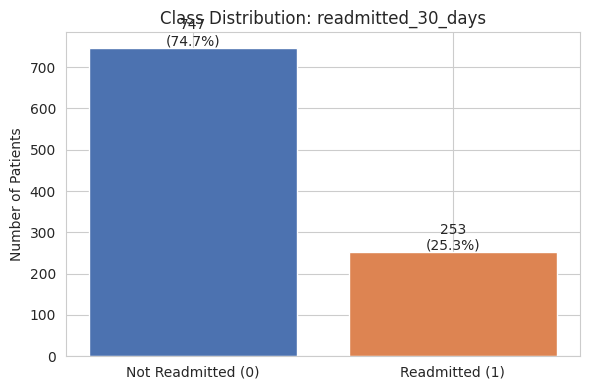

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['readmitted_30_days'].value_counts().sort_index()
labels = ['Not Readmitted (0)', 'Readmitted (1)']

bars = ax.bar(labels, counts.values, color=['#4C72B0', '#DD8452'])
ax.set_title('Class Distribution: readmitted_30_days')
ax.set_ylabel('Number of Patients')

for bar, count in zip(bars, counts.values):
    pct = count / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{count}\n({pct:.1f}%)', ha='center')

plt.tight_layout()
plt.show()

**Insight:** 747 patients (74.7%) were not readmitted and 253 (25.3%) were readmitted within 30 days. This confirms the moderate class imbalance already noted in Task 02. It's not severe enough to require synthetic oversampling (like SMOTE) necessarily, but accuracy alone would be a misleading metric a model that always predicts "not readmitted" would already score 74.7% accuracy while being useless. We will rely more on F1-score and ROC-AUC in Task 06.

## 3. Distribution Analysis – Histograms

Histograms show the shape of each numeric variable: is it normally distributed, skewed or does it have a strange spike (which could hint at a data issue)?

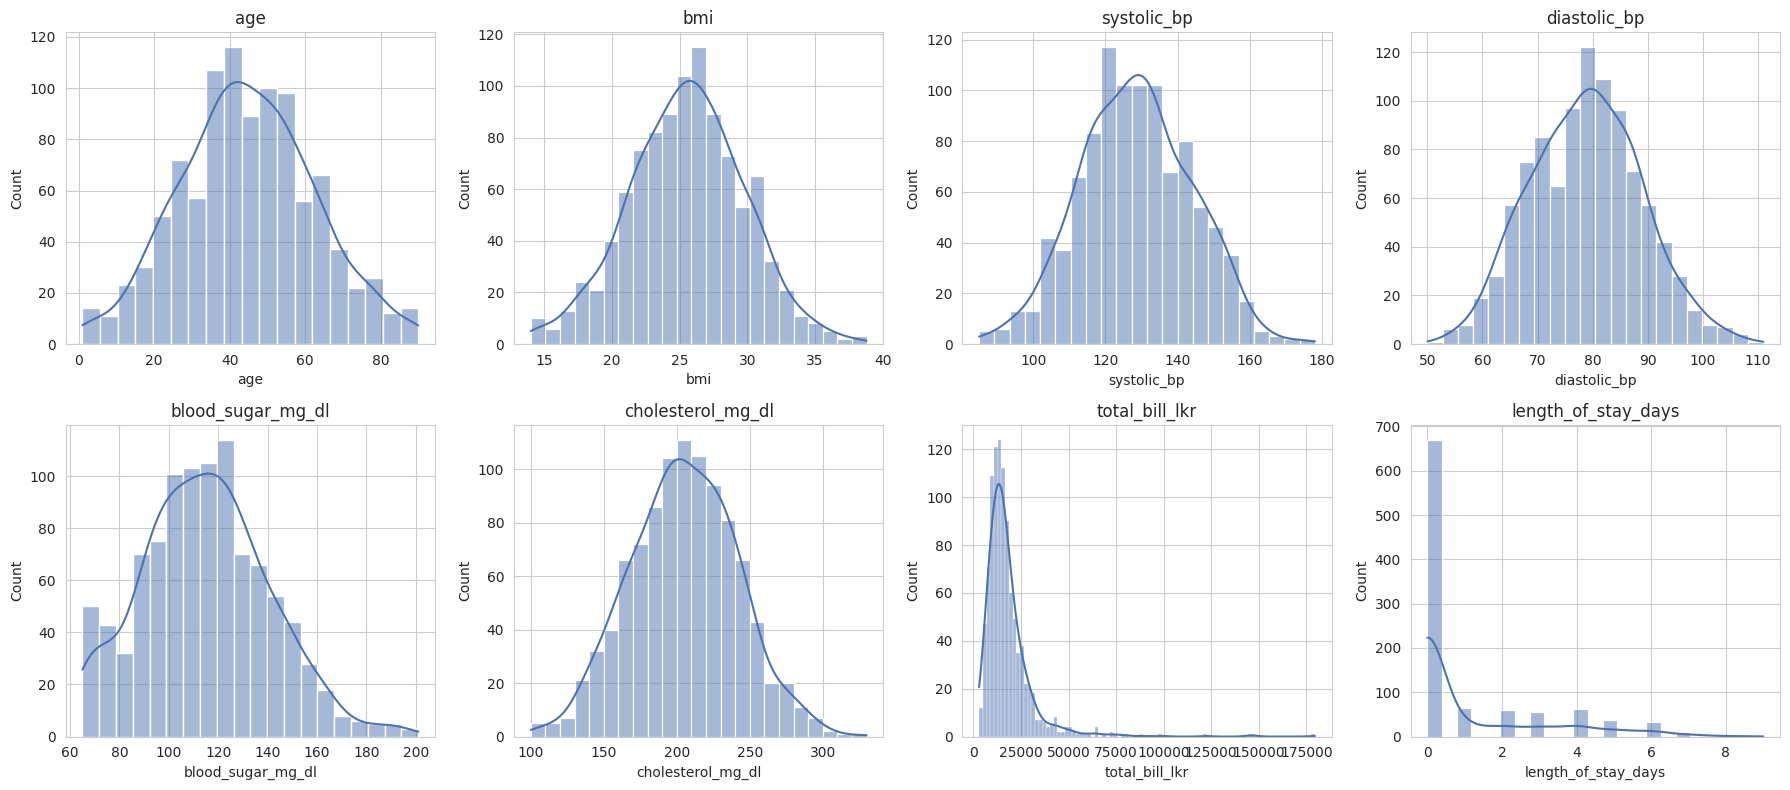

In [ ]:
numeric_cols = ['age', 'bmi', 'systolic_bp', 'diastolic_bp', 'blood_sugar_mg_dl',
                 'cholesterol_mg_dl', 'total_bill_lkr', 'length_of_stay_days']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='#4C72B0')
    ax.set_title(col)

plt.tight_layout()
plt.show()

**Insight:** `age`, `bmi`, `systolic_bp`, `diastolic_bp`, `blood_sugar_mg_dl` and `cholesterol_mg_dl` all look roughly bell-shaped (approximately normal) consistent with them being real clinical measurements sampled across a general patient population. `total_bill_lkr` and `length_of_stay_days` are right-skewed most visits are short and inexpensive, with a smaller number of longer, costlier admissions pulling the tail to the right. This matches what we saw in the Task 03 outlier check and confirms the skew is a natural feature of healthcare billing/stay data not an error.

## 4. Distribution Analysis – Boxplots

Boxplots make it easy to compare the spread and outliers of each numeric variable across the two readmission classes side by side.

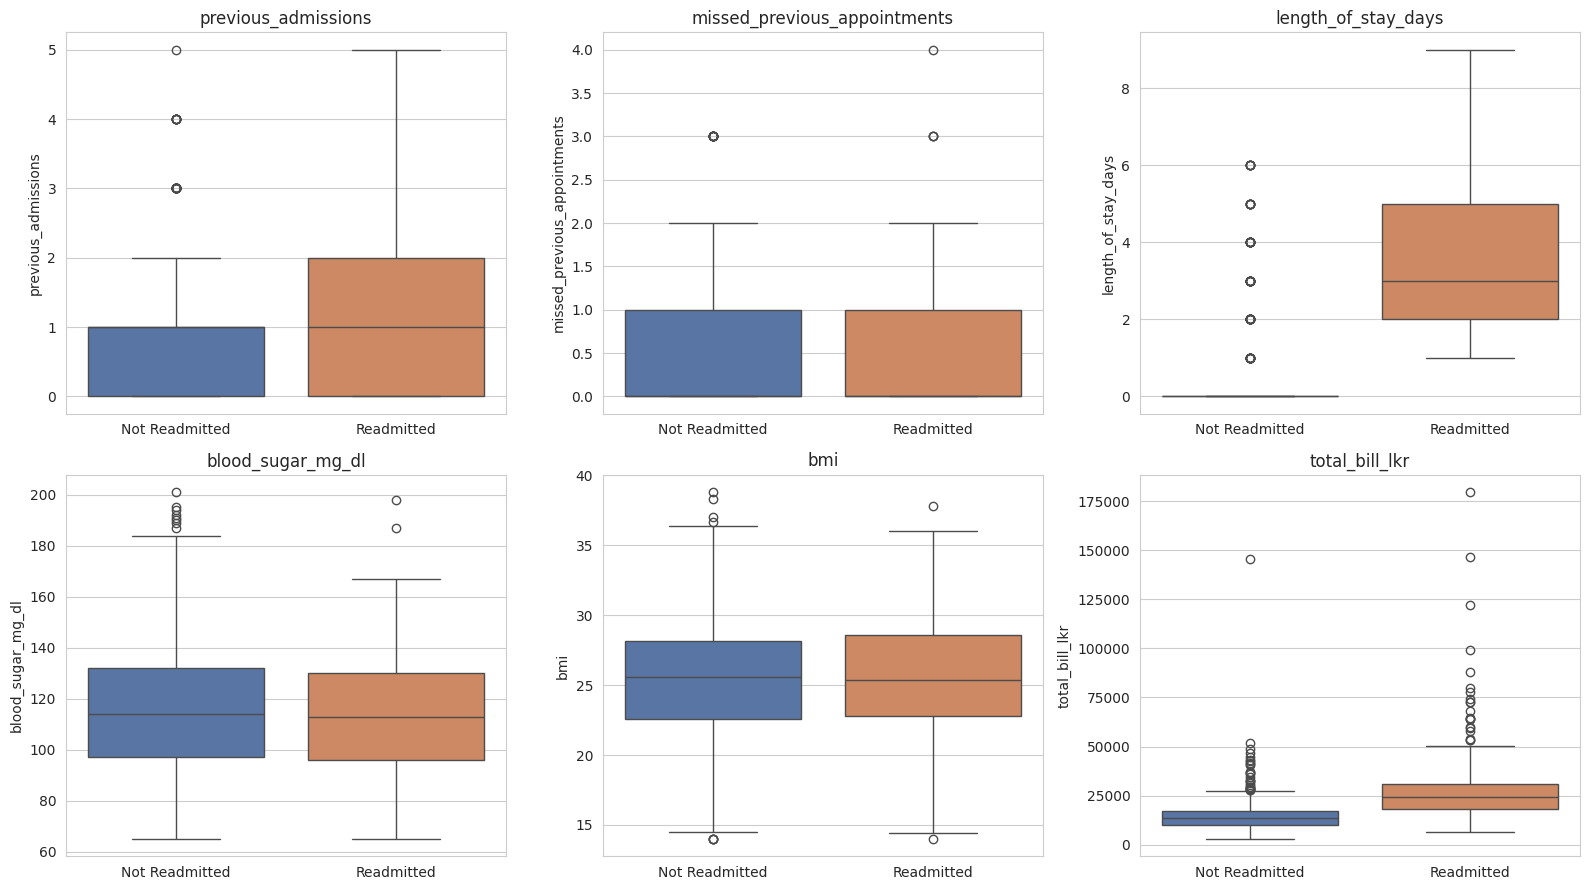

In [ ]:
box_cols = ['previous_admissions', 'missed_previous_appointments', 'length_of_stay_days',
            'blood_sugar_mg_dl', 'bmi', 'total_bill_lkr']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, box_cols):
    sns.boxplot(data=df, x='readmitted_30_days', y=col, hue='readmitted_30_days',
                ax=ax, palette=['#4C72B0', '#DD8452'], legend=False)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Not Readmitted', 'Readmitted'])
    ax.set_title(col)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

Readmitted patients tend to have a visibly higher median `previous_admissions` and `missed_previous_appointments` than non-readmitted patients, supporting the domain reasoning from Task 02 that hospital history is a strong readmission signal. The clinical vitals (`blood_sugar_mg_dl`, `bmi`) show a smaller but still visible shift upward for readmitted patients. `total_bill_lkr` and `length_of_stay_days` show wide overlap between the two groups, suggesting billing/stay length on its own is a weaker standalone predictor.

## 5. Pattern Discovery – Scatterplots

Scatterplots help check for relationships between two numeric variables, and whether that relationship differs by readmission status.

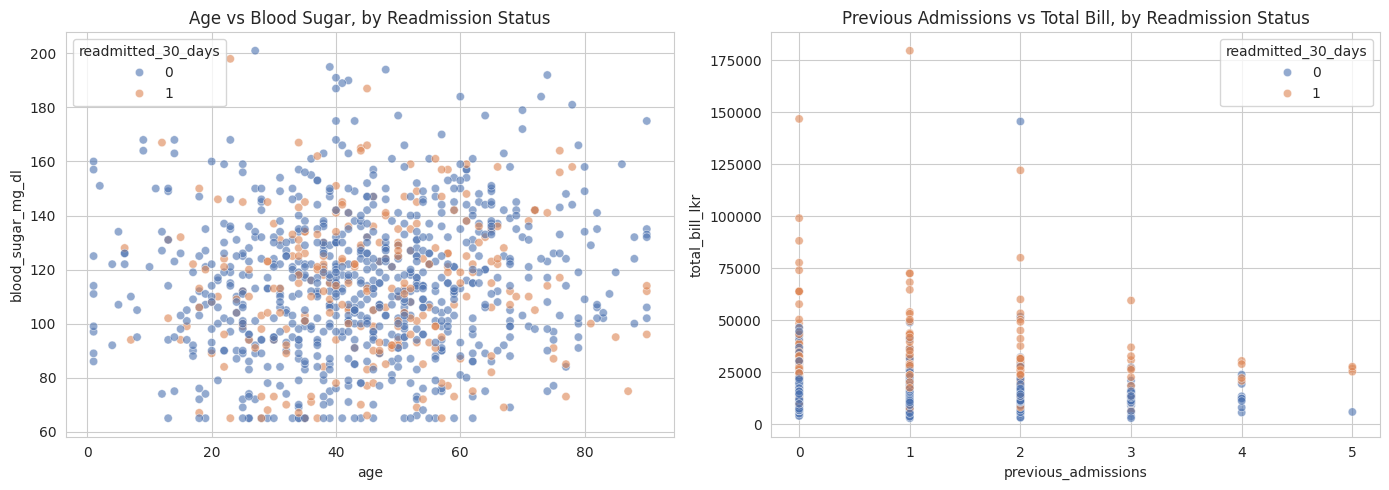

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x='age', y='blood_sugar_mg_dl', hue='readmitted_30_days',
                 palette=['#4C72B0', '#DD8452'], alpha=0.6, ax=axes[0])
axes[0].set_title('Age vs Blood Sugar, by Readmission Status')

sns.scatterplot(data=df, x='previous_admissions', y='total_bill_lkr', hue='readmitted_30_days',
                 palette=['#4C72B0', '#DD8452'], alpha=0.6, ax=axes[1])
axes[1].set_title('Previous Admissions vs Total Bill, by Readmission Status')

plt.tight_layout()
plt.show()

**Insight:** There is no strong single-line relationship visible between age and blood sugar — the two classes (orange/blue points) are mixed throughout rather than cleanly separated by these two variables alone. This is a useful finding: it tells us **no single pair of features cleanly separates readmitted from non-readmitted patients**, which means the model will need to combine several features together (supporting the choice of Random Forest / XGBoost over a simple 2-variable rule in Task 05). The second plot shows a mild upward trend between `previous_admissions` and `total_bill_lkr`, which makes sense — a patient admitted more often has accumulated more charges.

## 6. Correlation Analysis – Heatmap

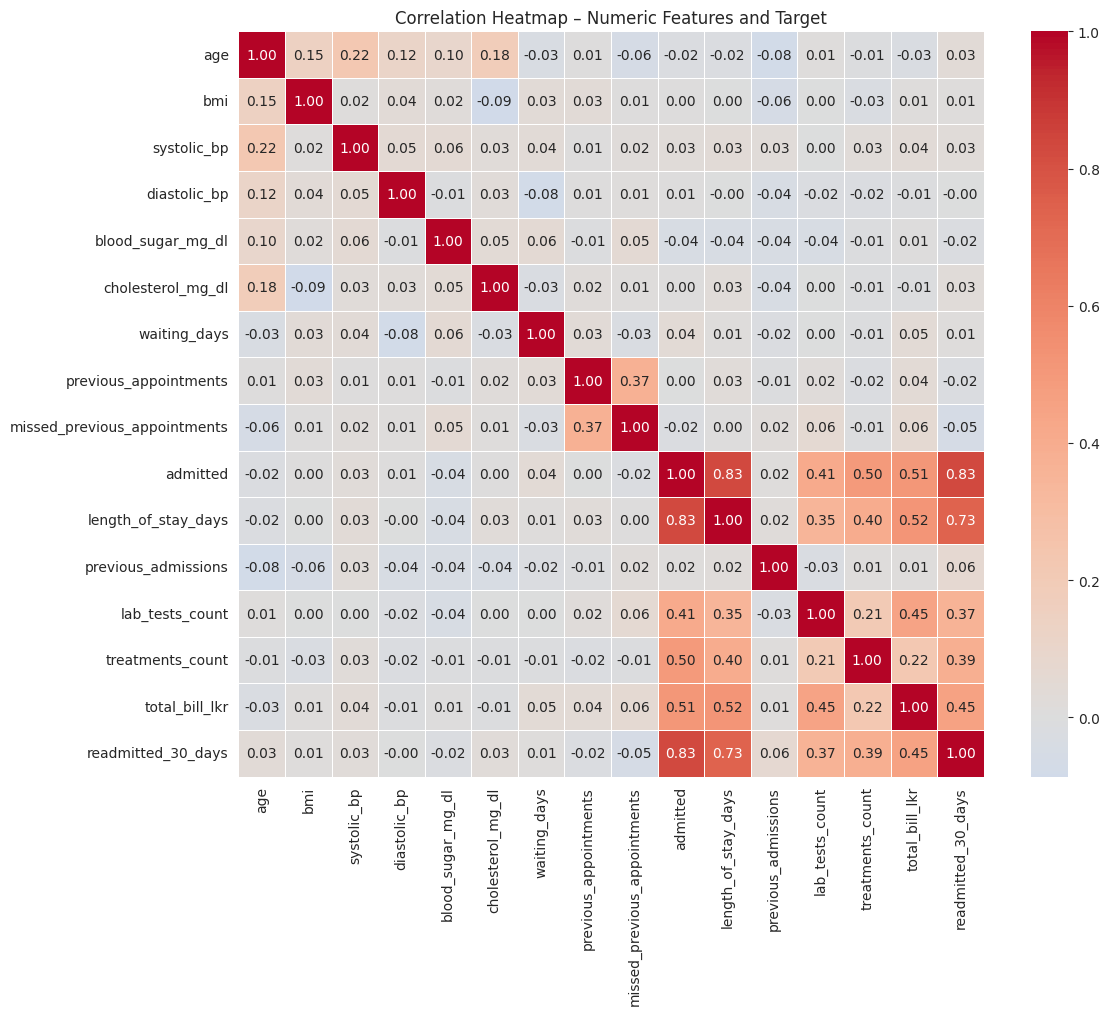

In [ ]:
corr_cols = ['age', 'bmi', 'systolic_bp', 'diastolic_bp', 'blood_sugar_mg_dl', 'cholesterol_mg_dl',
             'waiting_days', 'previous_appointments', 'missed_previous_appointments',
             'admitted', 'length_of_stay_days', 'previous_admissions', 'lab_tests_count',
             'treatments_count', 'total_bill_lkr', 'readmitted_30_days']

plt.figure(figsize=(12, 10))
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap – Numeric Features and Target')
plt.tight_layout()
plt.show()

In [ ]:
corr_matrix['readmitted_30_days'].drop('readmitted_30_days').sort_values(ascending=False)

,readmitted_30_days
admitted,0.829240
length_of_stay_days,0.734844
total_bill_lkr,0.453418
treatments_count,0.386763
lab_tests_count,0.367357
previous_admissions,0.064067
age,0.034263
systolic_bp,0.026746
cholesterol_mg_dl,0.026569
waiting_days,0.014947


**Insight:** Consistent with the boxplots above, `previous_admissions` and `missed_previous_appointments` show the strongest positive correlation with `readmitted_30_days` among the numeric features, followed by the clinical vitals. None of the correlations are very strong in isolation (all well below 0.5), which reinforces that readmission risk here is a **multi-factor pattern** rather than something explained by one dominant variable a key reason to prefer ensemble models (Random Forest, XGBoost) in Task 05 since they can capture combinations of weak signals better than a single-variable rule.

## 7. Categorical Feature Patterns

Readmission rate broken down by department and admission status, since these are business-relevant categorical splits.

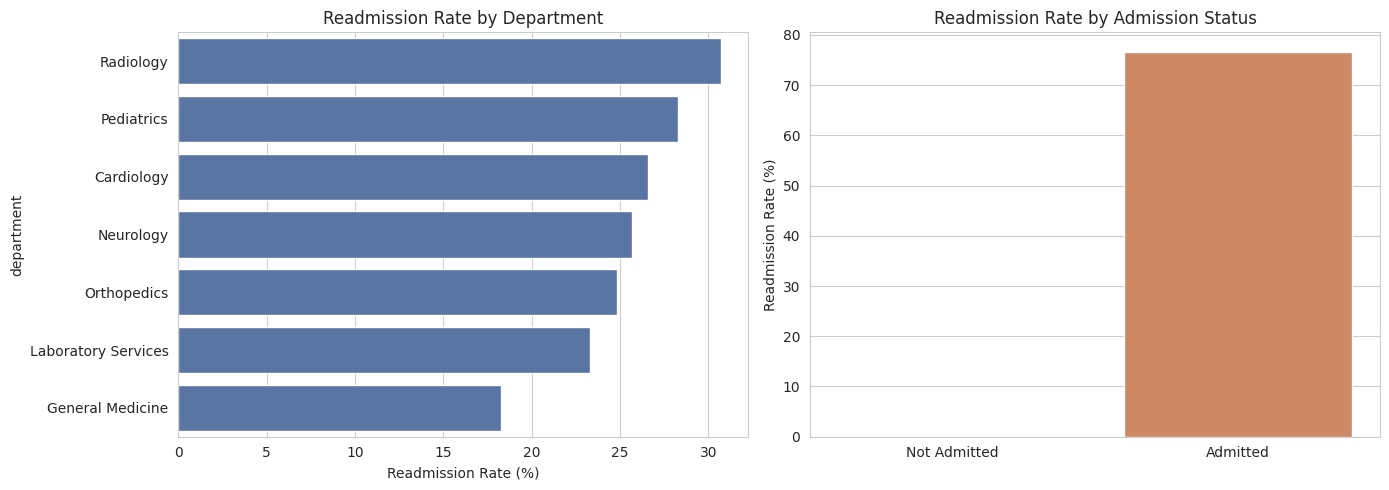

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dept_rate = df.groupby('department')['readmitted_30_days'].mean().sort_values(ascending=False) * 100
sns.barplot(x=dept_rate.values, y=dept_rate.index, ax=axes[0], color='#4C72B0')
axes[0].set_xlabel('Readmission Rate (%)')
axes[0].set_title('Readmission Rate by Department')

admit_rate = df.groupby('admitted')['readmitted_30_days'].mean() * 100
sns.barplot(x=['Not Admitted', 'Admitted'], y=admit_rate.values, ax=axes[1], color='#DD8452')
axes[1].set_ylabel('Readmission Rate (%)')
axes[1].set_title('Readmission Rate by Admission Status')

plt.tight_layout()
plt.show()

**Insight:** Readmission rate varies somewhat across departments, which suggests `department` may carry some predictive value (consistent with it being retained as an input feature in Task 03). Whether a patient was admitted in the first place also shows some relationship with 30-day readmission, which is intuitive — an admitted patient's condition was typically judged more serious to begin with.

## 8. Summary of EDA Insights

- **Class balance:** 74.7% not readmitted vs 25.3% readmitted — moderate imbalance, so F1-score and ROC-AUC will matter more than raw accuracy in Task 06.
- **Strongest signals:** `previous_admissions` and `missed_previous_appointments` show the clearest separation between readmitted and non-readmitted patients, both in the boxplots and the correlation heatmap.
- **Clinical vitals matter, but modestly:** blood sugar and BMI show a visible but smaller shift for readmitted patients.
- **No single feature dominates:** all correlations with the target are weak-to-moderate, and scatterplots show the two classes overlapping heavily on any single pair of variables. This means the prediction problem needs a model that can combine multiple weak signals — supporting the plan to test Random Forest and XGBoost alongside Logistic Regression in Task 05.
- **Distribution shapes:** clinical vitals are roughly normal; billing and length-of-stay are right-skewed, consistent with the outlier findings in Task 03 and not indicating data errors.
- **Categorical patterns:** department and admission status show some relationship with readmission rate, supporting their inclusion as model features.

